# 肥胖等级多分类（固定最优超参数版）

本笔记本将 `model.ipynb` 中 **GridSearchCV（7 折分层、`f1_macro`）** 得到的各模型**最优超参数**写死为最终模型，不再重复网格搜索。

**数据与划分**：与 `model.ipynb` 一致（`RANDOM_STATE=42`、`stratify`、特征中 `bool`→`int8`），以便与调参结果可比。

**以下为各模型在 GridSearch 中的最优参数摘要**（详见下方训练代码中的中文注释）：

| 模型 | 最优参数 |
|------|----------|
| 逻辑回归（Pipeline） | `C≈460`，`penalty=l2`，`solver=lbfgs` |
| 决策树 | `max_depth=None`，`max_leaf_nodes=128`，`min_samples_split=2`，`min_samples_leaf=1`，`ccp_alpha=0` |
| 随机森林 | `n_estimators=400`，`max_depth=None`，`max_features=0.65`，`min_samples_split=2`，`min_samples_leaf=1` |
| XGBoost | `n_estimators=200`，`max_depth=8`，`learning_rate=0.1`，`min_child_weight=1`，`subsample=0.9`，`colsample_bytree=0.9` |

**输出**：结果汇总表、四个模型的混淆矩阵热力图、各模型**全部特征**重要性（表格）及 **Top 10** 条形图。


In [1]:
# ---------- 依赖安装 ----------
# %pip：在「当前 Jupyter 内核」对应的 Python 环境中安装包，避免与系统 python 混用。
# -q：安静模式，减少安装日志输出。
# scikit-learn：机器学习模型与评估指标。
# pandas：读 Excel/表格数据。
# openpyxl：pandas 读取 .xlsx 所需引擎。
# xgboost：梯度提升树模型 XGBoost。
# numpy：数值计算。
# matplotlib / seaborn：绑图与统计图。
# 仅需成功运行一次；装完后若仍报错，请 Kernel → Restart Kernel 再运行后续单元。
%pip install -q scikit-learn pandas openpyxl xgboost numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---------- 标准库 ----------
import json  # 将超参数字典格式化为多行字符串，便于写入结果表
import warnings

warnings.filterwarnings("ignore")  # 忽略 sklearn/xgboost 等库的无关告警，输出更干净

# ---------- Jupyter 展示 ----------
from IPython.display import display  # 在笔记本里美观显示 DataFrame（表格）

# ---------- 绑图与数值 ----------
import matplotlib.pyplot as plt  # 绑图基础接口
import numpy as np  # 数组与数值运算
import pandas as pd  # 表格数据 DataFrame
import seaborn as sns  # 基于 matplotlib 的统计图，这里用于热力图

# ---------- 机器学习：模型 ----------
from sklearn.ensemble import RandomForestClassifier  # 随机森林：多棵决策树投票/平均
from sklearn.linear_model import LogisticRegression  # 逻辑回归：多分类用 softmax/一对多
from sklearn.tree import DecisionTreeClassifier  # 单棵决策树

# ---------- 机器学习：评估指标 ----------
from sklearn.metrics import (
    accuracy_score,  # 准确率：预测正确的样本比例
    classification_report,  # 按类别的 precision/recall/f1 文本报告
    confusion_matrix,  # 混淆矩阵：真实类 vs 预测类 的计数表
    f1_score,  # F1：精确率与召回率的调和平均；macro=各类别未加权平均，weighted=按支持度加权
    precision_score,  # 精确率：预测为某类中真正为该类的比例
    recall_score,  # 召回率：某类样本中被正确找出的比例
)

# ---------- 机器学习：数据划分与交叉验证 ----------
from sklearn.model_selection import (
    StratifiedKFold,  # 分层 K 折：每折中各类别比例与全集相近
    cross_val_score,  # 在训练集上做交叉验证得分
    train_test_split,  # 训练集 / 测试集划分
)
from sklearn.pipeline import Pipeline  # 串联步骤：例如先标准化再分类
from sklearn.preprocessing import (
    LabelEncoder,  # 把类别名映射为 0,1,2,... 整数（XGBoost 需要数值标签）
    StandardScaler,  # 标准化：每特征零均值单位方差，逻辑回归前常用
)

# ---------- XGBoost（可选） ----------
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None  # 未安装时后续单元会跳过 XGBoost

In [3]:
# ---------- 全局配置（与 model.ipynb 中 GridSearch 时一致，便于复现结果）----------

# RANDOM_STATE：随机种子。固定后，train_test_split、树模型、交叉验证折划分等可重复。
RANDOM_STATE = 42

# TEST_SIZE：测试集占全数据比例。0.2 表示 80% 训练、20% 测试。
TEST_SIZE = 0.2

# CV_N_SPLITS：分层 K 折交叉验证的折数 K。越大估计越稳，但计算更慢。
CV_N_SPLITS = 7

# SEVERITY_ORDER：肥胖等级标签的「有序」顺序（从瘦到胖），便于分类与排序展示。
SEVERITY_ORDER = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

In [4]:
# ---------- 辅助函数：汇总指标与交叉验证稳定性 ----------


def _format_best_params(best_params):
    """把超参数字典转成多行 JSON 字符串，写入表格时不易被截断。"""
    if isinstance(best_params, dict):
        return json.dumps(best_params, ensure_ascii=False, indent=2, default=str)
    return str(best_params)


def _collect_result(model_name, best_params, best_cv_score, stability, y_test, y_pred):
    """
    统一收集单个模型在测试集上的各项指标，便于做成一张总表。

    参数含义：
    - model_name：模型名称（字符串）
    - best_params：该模型使用的超参数字典（用于存档展示）
    - best_cv_score：交叉验证得到的 macro F1 均值（与 GridSearch 时的主指标一致）
    - stability：含 cv_mean_macro_f1、cv_std_macro_f1，反映训练集上 CV 的均值与波动
    - y_test：测试集真实标签
    - y_pred：模型对测试集的预测标签
    """
    # 测试集准确率：预测与真实完全一致的样本占比
    acc = accuracy_score(y_test, y_pred)
    # macro F1：每个类别先算 F1，再对类别简单平均（不随样本量加权），适合类别不均衡时看整体
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    # weighted F1：按各类支持度（样本数）加权平均的 F1，更贴近「总体分类正确程度」
    weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    # 宏平均 / 加权平均 的精确率、召回率
    prec_m = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_m = recall_score(y_test, y_pred, average="macro", zero_division=0)
    prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec_w = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    return {
        "model": model_name,
        "best_params": _format_best_params(best_params),
        "best_cv_macro_f1": round(best_cv_score, 5),
        "cv_mean_macro_f1": stability["cv_mean_macro_f1"],
        "cv_std_macro_f1": round(stability["cv_std_macro_f1"], 5),
        "test_accuracy": round(acc, 5),
        "test_macro_f1": round(macro_f1, 5),
        "test_weighted_f1": round(weighted_f1, 5),
        "test_precision_macro": round(prec_m, 5),
        "test_recall_macro": round(rec_m, 5),
        "test_precision_weighted": round(prec_w, 5),
        "test_recall_weighted": round(rec_w, 5),
    }


def _stability_cv(estimator, X_train, y_train, cv_splitter):
    """
    在训练集上做 K 折交叉验证，主指标为 f1_macro（与 model.ipynb 一致）。

    - estimator：已设好超参数的分类器（或 Pipeline）
    - cv_splitter：例如 StratifiedKFold，保证每折类别比例接近全训练集
    - n_jobs=-1：使用所有 CPU 核心并行计算各折（若机器较慢可改为 1）
    """
    scores = cross_val_score(
        estimator,
        X_train,
        y_train,
        cv=cv_splitter,
        scoring="f1_macro",
        n_jobs=-1,
    )
    return {
        "cv_mean_macro_f1": float(np.mean(scores)),  # K 折 macro F1 的均值
        "cv_std_macro_f1": float(np.std(scores)),  # K 折标准差：越小通常越稳定
    }


def _stability_cv_xgb(xgb_model, X_train, y_train_int, cv_splitter):
    """
    与 _stability_cv 相同，但 XGBoost 使用整数编码标签 y_train_int（0~K-1）。
    """
    scores = cross_val_score(
        xgb_model,
        X_train,
        y_train_int,
        cv=cv_splitter,
        scoring="f1_macro",
        n_jobs=-1,
    )
    return {
        "cv_mean_macro_f1": float(np.mean(scores)),
        "cv_std_macro_f1": float(np.std(scores)),
    }

## 1. 读取数据与训练/测试划分

- **数据文件**：`Obesity_Data_clean_onehot.xlsx`（特征已编码，本笔记不再做 one-hot）。
- **目标列**：`obesity_level` 转为有序分类 `Categorical`，顺序由 `SEVERITY_ORDER` 定义。
- **特征矩阵**：去掉目标列得到 `X`；布尔列转为 `int8` 便于数值计算。
- **划分**：`train_test_split` 使用 `test_size=0.2`、`random_state=42`、`stratify=y`，使训练/测试各类比例与总体一致。
- **交叉验证**：`StratifiedKFold` 仅用于在**训练集**上估计 macro F1 的均值与标准差，**不**把测试集卷入调参。


In [5]:
# ---------- 步骤 1：读入 Excel ----------
# 数据已做过 one-hot 等预处理，本笔记不再编码类别特征。
path = "Obesity_Data_clean_onehot.xlsx"
df = pd.read_excel(path)
print("数据集形状:", df.shape)
print("列名列表:", list(df.columns))

# ---------- 步骤 2：目标列有序分类 ----------
if "obesity_level" not in df.columns:
    raise ValueError("缺少目标列 obesity_level，请检查 Excel 列名。")
# categories=SEVERITY_ORDER：规定类别顺序；ordered=True：有序，便于与标签编码一致
df["obesity_level"] = pd.Categorical(
    df["obesity_level"], categories=SEVERITY_ORDER, ordered=True
)

# ---------- 步骤 3：划分特征矩阵 X 与目标向量 y ----------
X = df.drop(columns=["obesity_level"])  # 特征：除目标外所有列
y = df["obesity_level"]  # 目标：肥胖等级

# sklearn 多数模型更偏好数值型；将布尔列转为 0/1（int8 省内存）
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(np.int8)

# ---------- 步骤 4：训练集 / 测试集划分 ----------
# stratify=y：按 y 的类别比例分层抽样，使训练/测试集中各类比例接近全数据，减轻偶然偏差
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
print("训练集:", X_train.shape, "测试集:", X_test.shape)

# ---------- 步骤 5：交叉验证分割器（仅用于在训练集上算 CV 指标）----------
# shuffle=True：划分折前先打乱索引，再分层；与 random_state 一起保证可复现
cv_splitter = StratifiedKFold(
    n_splits=CV_N_SPLITS, shuffle=True, random_state=RANDOM_STATE
)

# results_rows：每个模型一行指标，最后拼成总表
results_rows = []
# trained：保存已 fit 的模型，供后面「特征重要性」单元使用
trained = {}

数据集形状: (2076, 15)
列名列表: ['gender', 'age', 'height', 'weight', 'family_history', 'high_cal_food', 'snacking', 'smoking', 'physical_activity', 'screen_time', 'alcohol', 'obesity_level', 'transport_1', 'transport_2', 'transport_3']
训练集: (1660, 14) 测试集: (416, 14)


## 2. 逻辑回归（最优参数来自 model.ipynb 多轮 GridSearch）

- **结构**：`Pipeline`：先 `StandardScaler`（消除量纲），再 `LogisticRegression`（多分类）。
- **主要超参数含义**：
  - **C**：正则化强度倒数，越大越贴近训练数据、可能更复杂。
  - **penalty=l2**：对权重的平方和惩罚，权重更平滑。
  - **solver=lbfgs**：拟牛顿法，适合本任务的多分类 + l2。
  - **max_iter**：最大迭代次数，保证收敛。
- 下方代码逐步：`fit` 训练 → `predict` 得到测试集预测 → `_stability_cv` 在训练集上做 K 折评估 → `_collect_result` 汇总一行指标。


In [6]:
# =============================================================================
# 模型 1：逻辑回归（Linear Model + 多分类）
# Pipeline：先 StandardScaler，再 LogisticRegression。与 model.ipynb 调参时结构一致。
# =============================================================================

# 以下为 GridSearchCV 得到的最优超参数（写入字典便于汇总表展示）
lr_params = {
    # C：正则化强度的倒数。C 越大，对训练误差惩罚越弱、模型更复杂；过小则欠拟合。
    "clf__C": 460.0,  # model.ipynb 数值约为 459.99999999999994，这里取 460.0
    # penalty：正则化类型。l2 = 权重平方和惩罚，权重趋向平滑、通常更稳。
    "clf__penalty": "l2",
    # solver：优化算法。lbfgs 适合中小数据、多分类、l2，收敛可靠。
    "clf__solver": "lbfgs",
}

pipe_lr = Pipeline(
    [
        # 第一步：StandardScaler — 各特征零均值、方差 1，避免量纲大的特征主导梯度
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                # max_iter：迭代上限；多分类 + 大数据时需足够大以保证收敛
                max_iter=10000,
                # random_state：仅影响优化中的伪随机性（若 solver 用到），固定可复现
                random_state=RANDOM_STATE,
                C=lr_params["clf__C"],
                penalty=lr_params["clf__penalty"],
                solver=lr_params["clf__solver"],
            ),
        ),
    ]
)

# fit：在训练集上学习标准化参数与回归系数
pipe_lr.fit(X_train, y_train)
# predict：对测试集做类别预测（多分类默认 softmax / 一对多，由 sklearn 实现）
y_pred_lr = pipe_lr.predict(X_test)

# 在训练集上做 7 折交叉验证，得到 macro F1 的均值与标准差（反映泛化稳定性）
stab_lr = _stability_cv(pipe_lr, X_train, y_train, cv_splitter)
cv_lr_mean = stab_lr["cv_mean_macro_f1"]  # 作为表中「best_cv_macro_f1」展示用

row_lr = _collect_result(
    "Logistic Regression (最优参数固定)",
    lr_params,
    cv_lr_mean,
    stab_lr,
    y_test,
    y_pred_lr,
)
results_rows.append(row_lr)
trained["lr"] = pipe_lr  # 保存 pipeline，后续「特征重要性」用系数绝对值近似
print("逻辑回归 训练完成。测试 Macro F1:", row_lr["test_macro_f1"])

逻辑回归 训练完成。测试 Macro F1: 0.96089


## 3. 决策树（最优参数固定）

- **max_depth**：限制树深；`None` 表示深度由其它停止条件决定。
- **max_leaf_nodes**：最多叶子数，直接限制模型容量。
- **min_samples_split / min_samples_leaf**：节点分裂与叶子的最小样本数，越大树越「粗」、越不易过拟合。
- **ccp_alpha**：代价复杂度剪枝；`0` 表示不在此框架下额外剪枝。
- **class_weight=balanced**：按类别频率自动加权，缓解类别不平衡。


In [7]:
# =============================================================================
# 模型 2：决策树（单棵树，可解释性强）
# =============================================================================

dt_params = {
    # max_depth：树的最大深度。None 表示不限制深度，直到叶节点纯净或受其他参数约束
    "max_depth": None,
    # min_samples_split：分裂内部节点时，该节点至少需要的样本数；越大越保守、防过拟合
    "min_samples_split": 2,
    # min_samples_leaf：叶节点至少包含的样本数；越大叶越「粗」、模型越简单
    "min_samples_leaf": 1,
    # ccp_alpha：代价复杂度剪枝系数，越大剪枝越强；0 表示不启用该剪枝项
    "ccp_alpha": 0.0,
    # max_leaf_nodes：最多叶节点个数；与 max_depth 等共同限制树规模，这里限制为 128
    "max_leaf_nodes": 128,
}

dt_model = DecisionTreeClassifier(
    # random_state：划分特征顺序、随机性（若 splitter 随机）时固定种子，保证可复现
    random_state=RANDOM_STATE,
    # class_weight：类别权重。balanced 按样本量自动加权，缓解类别不平衡
    class_weight="balanced",
    **{k: v for k, v in dt_params.items()},
)

dt_model.fit(X_train, y_train)  # 从根递归分裂，生成树结构
y_pred_dt = dt_model.predict(X_test)  # 从根走到叶，叶上多数类或概率最大类为预测

stab_dt = _stability_cv(dt_model, X_train, y_train, cv_splitter)
cv_dt_mean = stab_dt["cv_mean_macro_f1"]
row_dt = _collect_result(
    "Decision Tree (最优参数固定)",
    dt_params,
    cv_dt_mean,
    stab_dt,
    y_test,
    y_pred_dt,
)
results_rows.append(row_dt)
trained["dt"] = dt_model  # 后续 feature_importances_ 用
print("决策树 训练完成。测试 Macro F1:", row_dt["test_macro_f1"])

决策树 训练完成。测试 Macro F1: 0.94333


## 4. 随机森林（最优参数固定）

- **n_estimators**：森林中决策棵数；越多通常方差越小、计算越慢。
- **max_features**：每棵树每次分裂时随机考虑的特征比例（或个数），引入随机性、降低树之间相关性。
- 其余 `max_depth`、`min_samples_*` 含义与单棵决策树相同；**集成**时对多棵树预测做投票（分类）。


In [8]:
# =============================================================================
# 模型 3：随机森林（多棵决策树 + 集成）
# 每棵树用自助抽样（bootstrap）子样本、随机特征子集分裂，最后投票或平均概率。
# =============================================================================

rf_params = {
    # n_estimators：森林中树的数量；越多通常更稳但更慢
    "n_estimators": 400,
    # max_depth：单棵树最大深度；None 表示不单独限制（仍受 min_samples_* 等约束）
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    # max_features：每次分裂时随机考虑的特征数。0.65 表示取 65% 的特征数（约等于比例）
    "max_features": 0.65,
}

rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    **rf_params,
)

rf_model.fit(X_train, y_train)  # 训练所有树
# predict：各树投票得票最多的类别
y_pred_rf = rf_model.predict(X_test)

stab_rf = _stability_cv(rf_model, X_train, y_train, cv_splitter)
cv_rf_mean = stab_rf["cv_mean_macro_f1"]
row_rf = _collect_result(
    "Random Forest (最优参数固定)",
    rf_params,
    cv_rf_mean,
    stab_rf,
    y_test,
    y_pred_rf,
)
results_rows.append(row_rf)
trained["rf"] = rf_model  # 后续 feature_importances_（树平均不纯度下降等）
print("随机森林 训练完成。测试 Macro F1:", row_rf["test_macro_f1"])

随机森林 训练完成。测试 Macro F1: 0.9671


## 5. XGBoost（最优参数固定）

- **标签**：`LabelEncoder` 将肥胖等级转为 `0..K-1`，XGBoost 多分类要求整数标签。
- **n_estimators / learning_rate**：树棵数与每步学习率，二者权衡：学习率小通常需更多树。
- **max_depth**：单棵树最大深度。
- **subsample / colsample_bytree**：行、列采样比例，减轻过拟合。
- **min_child_weight**：叶子最小权重和，越大越保守。
- **eval_metric=mlogloss**：多分类对数损失，与训练目标一致；**n_jobs=1** 与外层交叉验证并行策略一致。


In [9]:
# =============================================================================
# 模型 4：XGBoost（梯度提升树，串行加树减小损失）
# 要求标签为 0 ~ num_class-1 的整数，故先用 LabelEncoder。
# =============================================================================

row_xgb = None
y_pred_xgb = None
le_xgb = None
xgb_model = None

if XGBClassifier is None:
    print("未安装 xgboost，跳过 XGBoost。")
else:
    # LabelEncoder：把肥胖等级字符串映射为 0,1,...,K-1，与 XGBoost 多分类接口一致
    le_xgb = LabelEncoder()
    le_xgb.fit(SEVERITY_ORDER)  # 固定类别顺序，与 SEVERITY_ORDER 一致
    y_train_xgb = le_xgb.transform(y_train.astype(str))

    # 以下为 GridSearch 搜索到的最优超参数
    xgb_search_params = {
        # n_estimators：提升轮数（树棵数）；越多容量越大，需配合学习率防过拟合
        "n_estimators": 200,
        # max_depth：每棵树的深度；越大越能拟合复杂关系，但更易过拟合
        "max_depth": 8,
        # learning_rate（eta）：每轮树的步长；越小需更多树，通常泛化更好
        "learning_rate": 0.1,
        # min_child_weight：叶节点所需的最小 Hessian 权重和（近似最小样本权重）；越大越保守
        "min_child_weight": 1,
        # subsample：每轮训练使用的行采样比例；<1 有随机性，减轻过拟合
        "subsample": 0.9,
        # colsample_bytree：每棵树建时使用的列采样比例
        "colsample_bytree": 0.9,
    }
    # 与 model.ipynb 中固定一致、未放入网格搜索的项
    xgb_fixed = dict(
        random_state=RANDOM_STATE,  # 随机种子：列采样、行采样等可复现
        eval_metric="mlogloss",  # 多分类常用负对数似然，与训练目标一致
        n_jobs=1,  # 单棵树内线程数；GridSearch 时避免与外层并行冲突常设为 1
    )
    try:
        # use_label_encoder=False：新版 xgboost 推荐显式关闭旧标签编码器接口
        xgb_model = XGBClassifier(**xgb_fixed, **xgb_search_params, use_label_encoder=False)
    except TypeError:
        xgb_model = XGBClassifier(**xgb_fixed, **xgb_search_params)

    xgb_model.fit(X_train, y_train_xgb)
    y_idx = xgb_model.predict(X_test)  # 输出整数类别索引
    # inverse_transform：把整数索引还原成原来的肥胖等级字符串，与 y_test 类型一致便于评估
    y_pred_xgb = le_xgb.inverse_transform(y_idx.astype(int))
    y_pred_xgb = pd.Categorical(y_pred_xgb, categories=SEVERITY_ORDER, ordered=True)

    stab_xgb = _stability_cv_xgb(xgb_model, X_train, y_train_xgb, cv_splitter)
    cv_xgb_mean = stab_xgb["cv_mean_macro_f1"]
    row_xgb = _collect_result(
        "XGBoost (最优参数固定)",
        {**xgb_fixed, **xgb_search_params, "note": "与 model.ipynb GridSearch 最优一致"},
        cv_xgb_mean,
        stab_xgb,
        y_test,
        y_pred_xgb,
    )
    results_rows.append(row_xgb)
    trained["xgb"] = xgb_model
    print("XGBoost 训练完成。测试 Macro F1:", row_xgb["test_macro_f1"])

XGBoost 训练完成。测试 Macro F1: 0.97507


## 6. 结果汇总表（更新自固定参数训练）

- 将前面各模型 `_collect_result` 得到的字典行合并为 `DataFrame`。
- **主表**：测试集 Accuracy、Macro F1、Weighted F1、CV 标准差、Macro Recall，以及完整 `best_params`。
- **附表**：macro / weighted 两种平均方式下的 Precision 与 Recall。
- 同时导出 **model_final_summary.csv**（UTF-8 带 BOM，方便 Excel 打开）。


In [10]:
# ---------- 将各模型一行指标合并为总表 ----------
results_df = pd.DataFrame(results_rows)

# 主表：测试集表现 + 交叉验证波动；列名改为中文友好显示
summary_display = results_df[
    [
        "model",  # 模型名称
        "best_params",  # 该模型使用的全部超参数（JSON 字符串）
        "test_accuracy",  # 测试集准确率
        "test_macro_f1",  # 测试集宏平均 F1（各类别同等重要）
        "test_weighted_f1",  # 测试集加权 F1（样本多的类权重大）
        "cv_std_macro_f1",  # 训练集 K 折 macro F1 的标准差：越小越稳定
        "test_recall_macro",  # 测试集宏平均召回率
    ]
].rename(
    columns={
        "test_accuracy": "Accuracy",
        "test_macro_f1": "Macro F1（主指标）",
        "test_weighted_f1": "Weighted F1",
        "cv_std_macro_f1": "CV std",
        "test_recall_macro": "Macro Recall",
    }
)

# 附表：精确率/召回率的 macro 与 weighted 两种平均方式
extra_display = results_df[
    [
        "model",
        "test_precision_macro",
        "test_recall_macro",
        "test_precision_weighted",
        "test_recall_weighted",
    ]
]

print(
    "\n========== 各模型结果汇总（Accuracy / Macro F1 / Weighted F1 / CV std / Macro Recall；best_params 完整）=========="
)
display(summary_display)  # 在 Jupyter 中渲染为 HTML 表格
print("\n========== 附：Precision / Recall（macro & weighted）==========")
display(extra_display)

# 导出 CSV：utf-8-sig 便于 Excel 直接打开不乱码
summary_csv = results_df.copy()
summary_csv.to_csv("model_final_summary.csv", index=False, encoding="utf-8-sig")
print("\n已保存: model_final_summary.csv")


========== 各模型结果汇总（Accuracy / Macro F1 / Weighted F1 / CV std / Macro Recall；best_params 完整）==========


,model,best_params,Accuracy,Macro F1（主指标）,Weighted F1,CV std,Macro Recall
0,Logistic Regression (最优参数固定),"{\n ""clf__C"": 460.0,\n ""clf__penalty"": ""l2"",...",0.96154,0.96089,0.96148,0.01166,0.96153
1,Decision Tree (最优参数固定),"{\n ""max_depth"": null,\n ""min_samples_split""...",0.94471,0.94333,0.94434,0.01825,0.94383
2,Random Forest (最优参数固定),"{\n ""n_estimators"": 400,\n ""max_depth"": null...",0.96875,0.96710,0.96862,0.02117,0.96788
3,XGBoost (最优参数固定),"{\n ""random_state"": 42,\n ""eval_metric"": ""ml...",0.97596,0.97507,0.97593,0.01193,0.97512



========== 附：Precision / Recall（macro & weighted）==========


,model,test_precision_macro,test_recall_macro,test_precision_weighted,test_recall_weighted
0,Logistic Regression (最优参数固定),0.96098,0.96153,0.96214,0.96154
1,Decision Tree (最优参数固定),0.94416,0.94383,0.94521,0.94471
2,Random Forest (最优参数固定),0.96755,0.96788,0.96961,0.96875
3,XGBoost (最优参数固定),0.97575,0.97512,0.97656,0.97596



已保存: model_final_summary.csv


## 7. 混淆矩阵热力图（四个模型）

- **行（True）**：真实肥胖等级；**列（Predicted）**：模型预测等级。
- **对角线**越大表示分对的越多；**非对角线**可看哪两类最易混淆。
- 每个模型单独保存一张 PNG（`confusion_matrix_*.png`）。


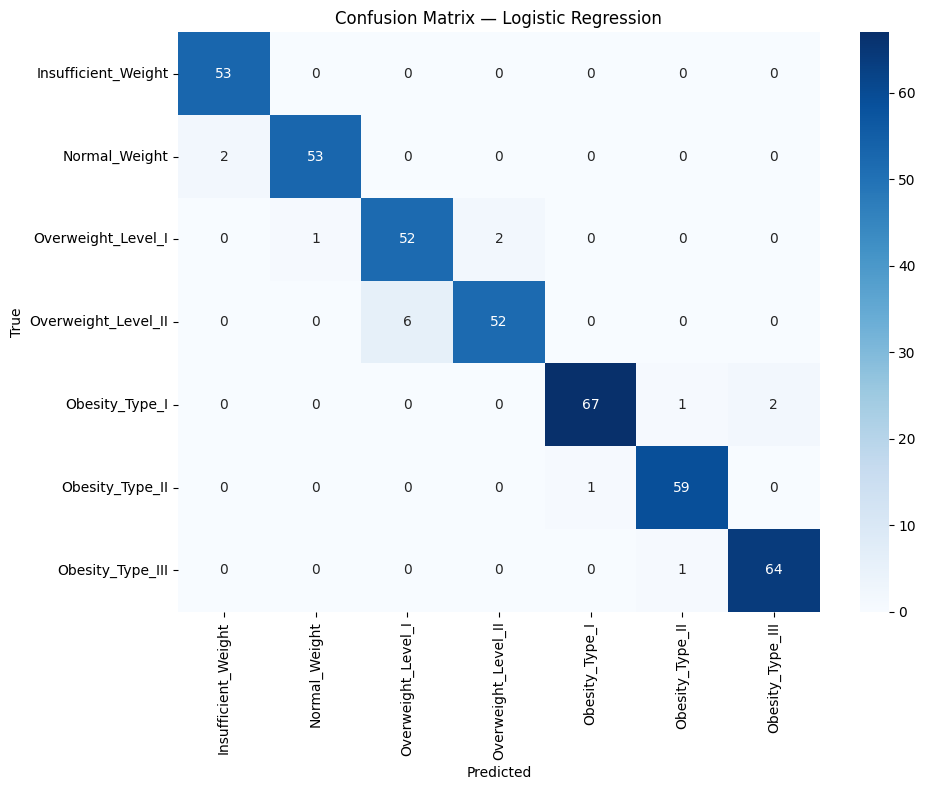

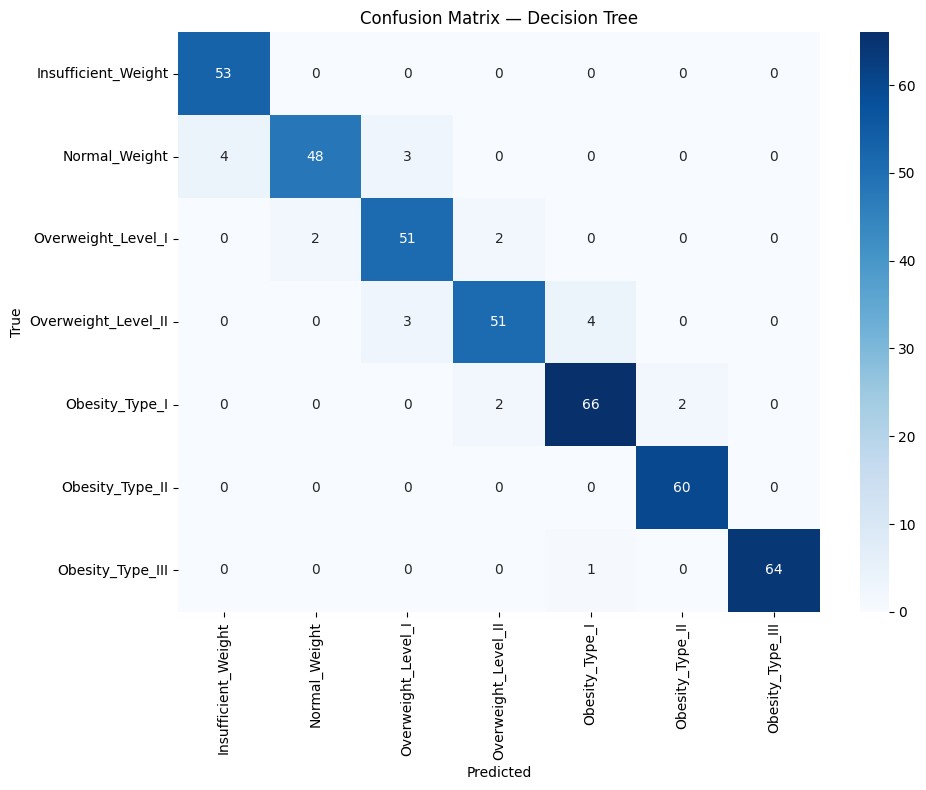

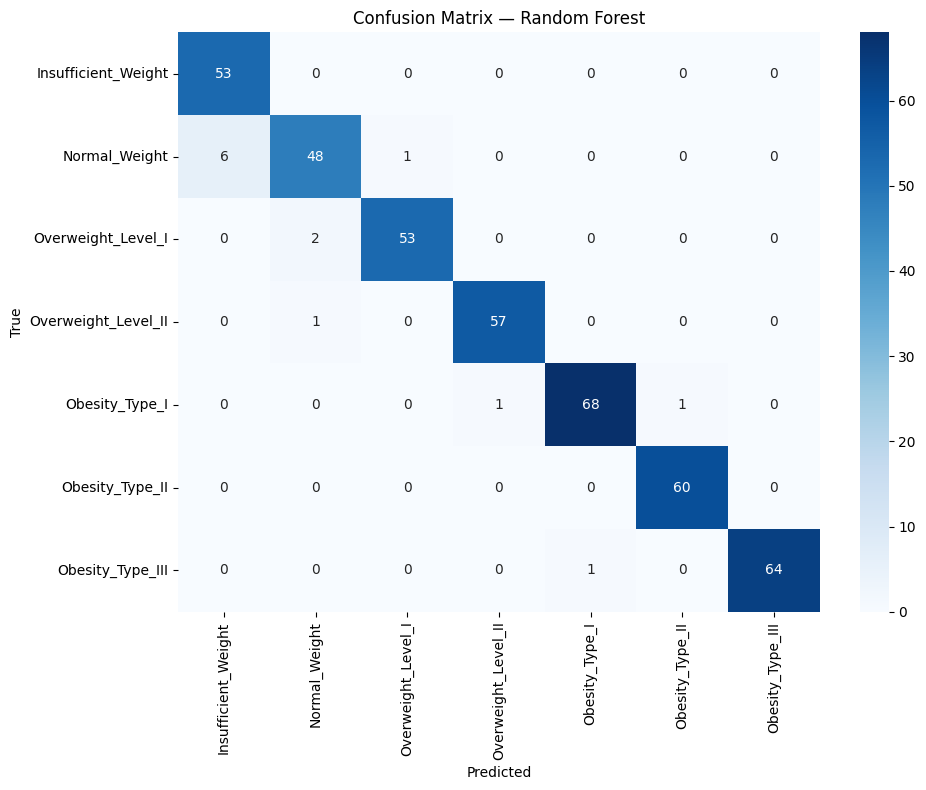

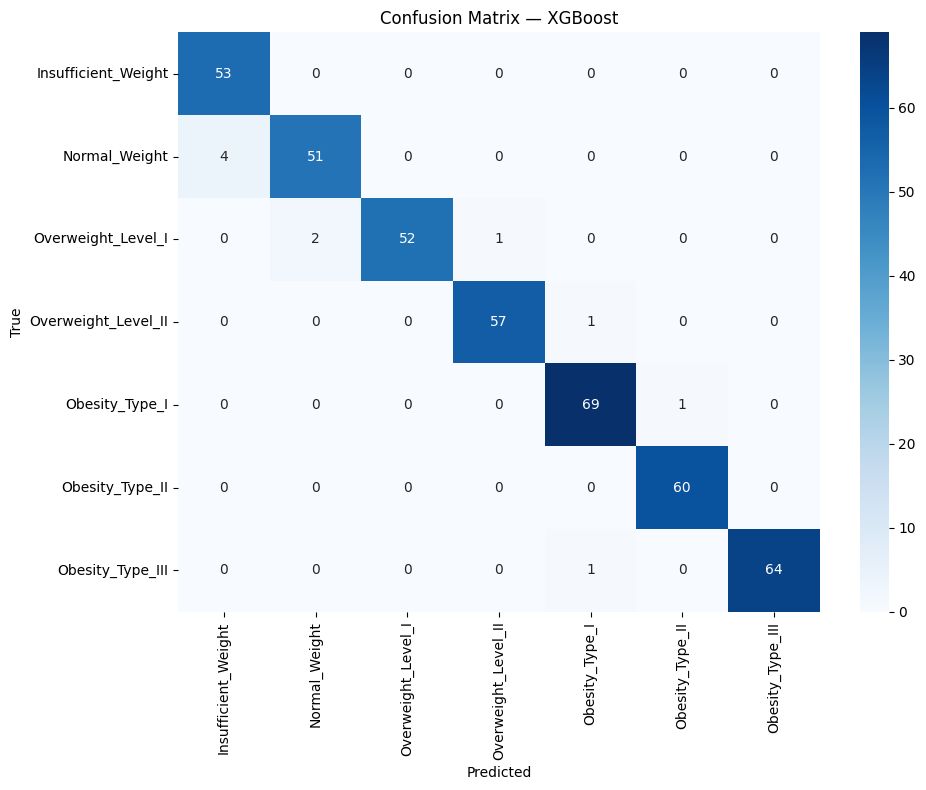

In [11]:
# ---------- 混淆矩阵热力图：逐模型对比「真实类别 vs 预测类别」 ----------
# 混淆矩阵元素 cm[i,j]：真实为第 i 类、预测为第 j 类的样本个数。
# labels=SEVERITY_ORDER：保证行列顺序与肥胖等级顺序一致，便于阅读。

preds = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
]
if y_pred_xgb is not None:
    preds.append(("XGBoost", y_pred_xgb))

for name, pred in preds:
    cm = confusion_matrix(y_test, pred, labels=SEVERITY_ORDER)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,  # 格内显示数值
        fmt="d",  # 整数格式
        cmap="Blues",  # 颜色越深表示样本数越多
        xticklabels=SEVERITY_ORDER,
        yticklabels=SEVERITY_ORDER,
    )
    plt.xlabel("Predicted")  # 横轴：模型预测的类别
    plt.ylabel("True")  # 纵轴：真实类别
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    safe = name.lower().replace(" ", "_")
    plt.savefig(f"confusion_matrix_{safe}.png", dpi=300)  # 高分辨率保存到当前目录
    plt.show()

## 8. 特征重要性

- **树模型 / 随机森林 / XGBoost**：使用 `feature_importances_`（基于不纯度下降等，已归一化为和为 1，仅相对比较）。
- **逻辑回归**：`coef_` 形状为（类别数 × 特征数），对各类别系数取绝对值后在**类别维**求平均，作为该特征「综合影响强度」的近似（非概率解释）。
- 每种模型：打印**全部特征**、保存 `*_importance_all.csv`，并绑制 **Top 10** 横向条形图 `*_importance_top10.png`。



========== Logistic Regression (|coef| 均值) — 全部特征重要性 ==========
weight               58.476663
height               16.581899
gender                9.428660
transport_2           2.161331
snacking              2.055074
transport_1           1.896039
transport_3           1.728874
screen_time           1.503272
alcohol               1.492623
age                   1.407261
physical_activity     1.391473
high_cal_food         1.340470
family_history        1.311830
smoking               0.209955


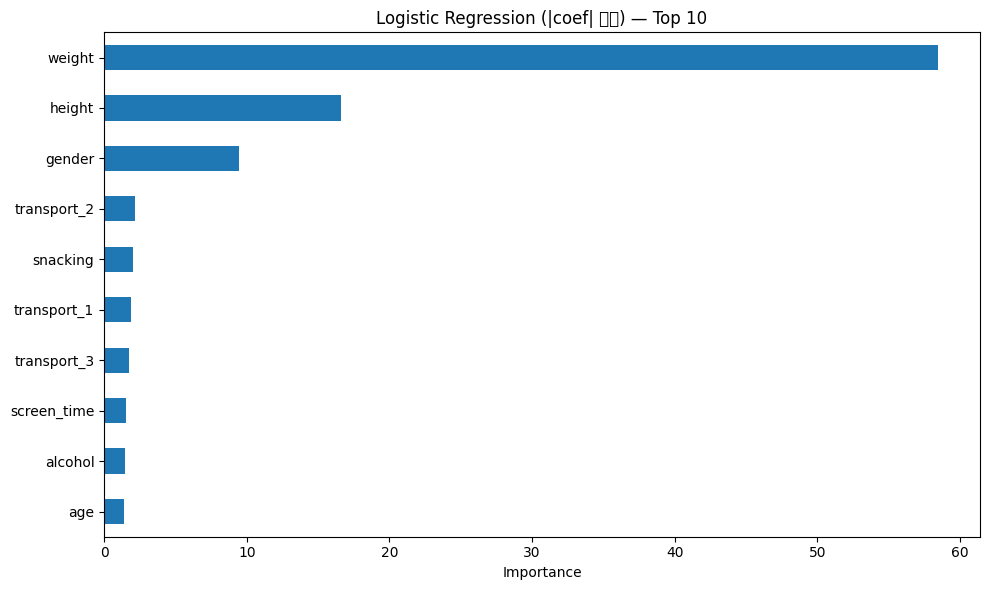


========== Decision Tree — 全部特征重要性 ==========
weight               0.454639
height               0.240289
gender               0.152923
age                  0.052131
alcohol              0.028909
high_cal_food        0.020367
snacking             0.015964
physical_activity    0.008858
screen_time          0.007170
transport_1          0.006044
smoking              0.004843
family_history       0.004406
transport_2          0.003456
transport_3          0.000000


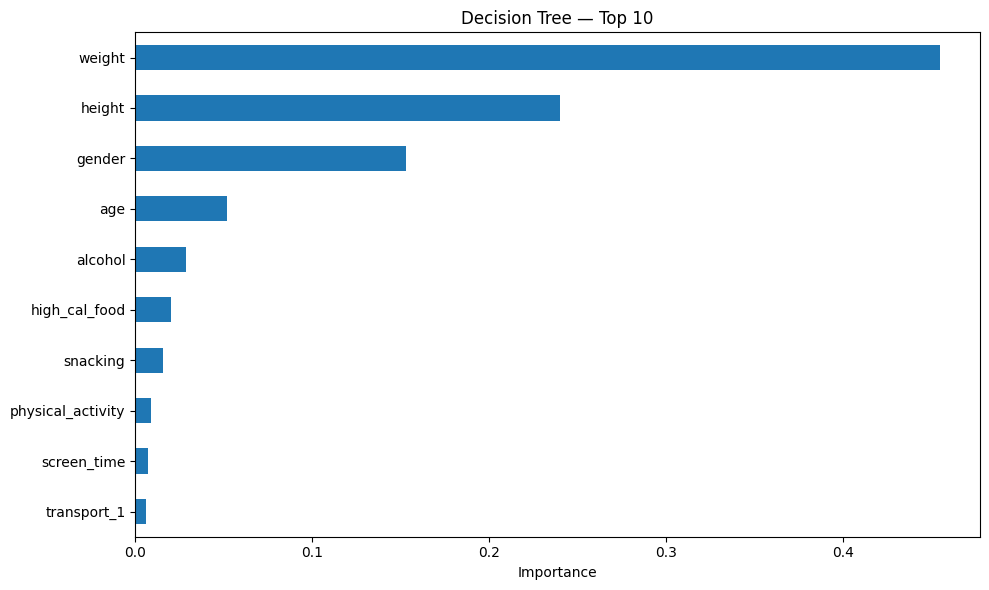


========== Random Forest — 全部特征重要性 ==========
weight               0.486857
height               0.192727
gender               0.116455
age                  0.074306
alcohol              0.022700
family_history       0.022592
snacking             0.021987
high_cal_food        0.018752
physical_activity    0.016892
screen_time          0.011774
transport_2          0.008705
transport_1          0.003354
smoking              0.002635
transport_3          0.000263


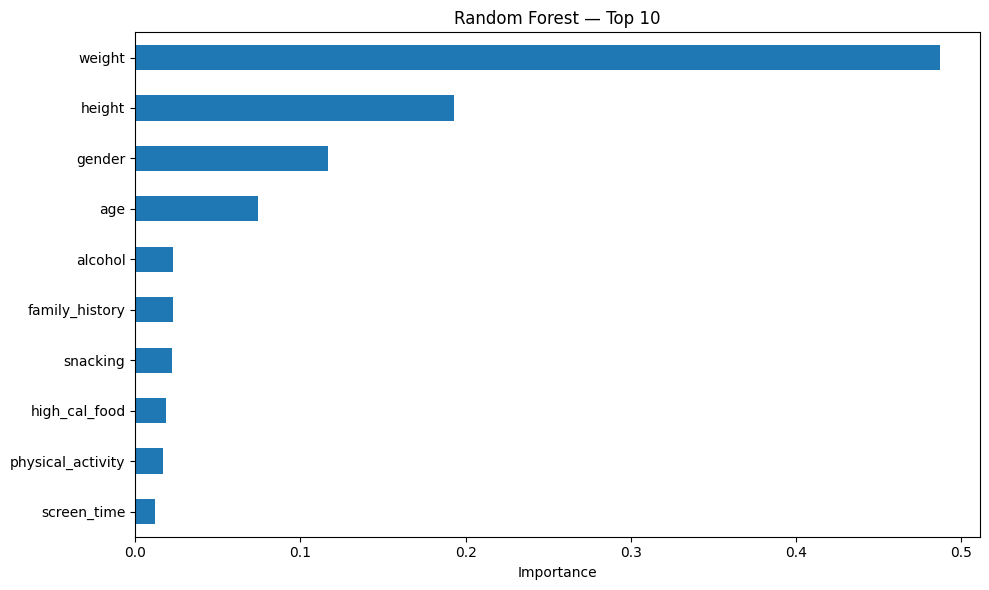


========== XGBoost — 全部特征重要性 ==========
gender               0.329542
weight               0.153129
transport_1          0.092027
alcohol              0.071731
height               0.056392
high_cal_food        0.056179
family_history       0.052728
smoking              0.049788
snacking             0.035344
transport_2          0.034067
age                  0.030964
physical_activity    0.021318
screen_time          0.016789
transport_3          0.000000


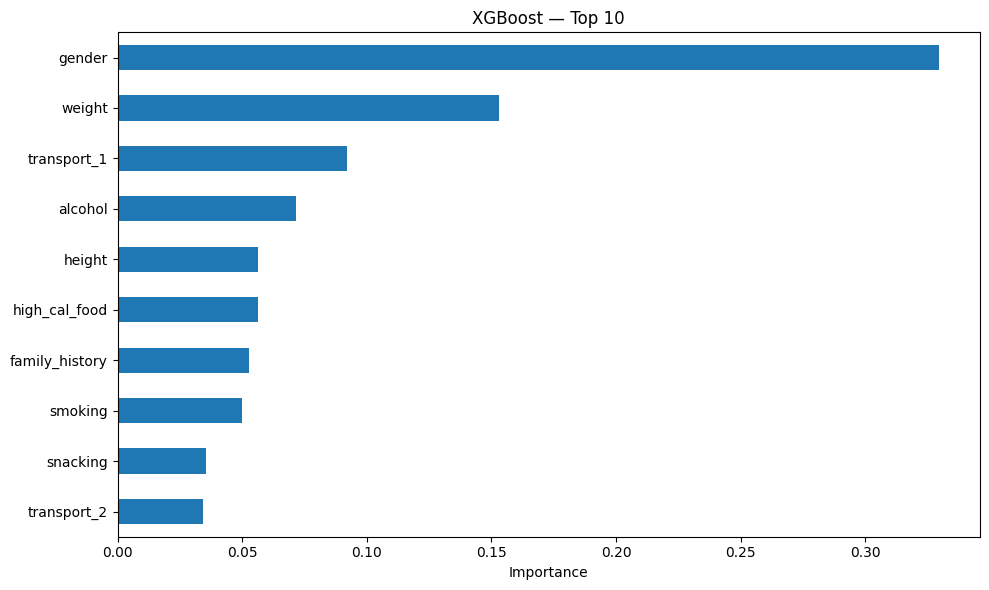

In [12]:
# ---------- 特征重要性：对比「哪些输入变量对预测贡献更大」 ----------
# 与训练时列顺序一致，用于给 Series 加索引名
feature_names = list(X_train.columns)


def plot_and_save_full_and_top10(series, title_prefix, fname_prefix):
    """
    打印并保存「全部特征」重要性，再绑制 Top 10 条形图。

    参数：
    - series：pd.Series，索引为特征名，值为重要性得分（越大越重要，仅相对比较）
    - title_prefix：图与打印标题前缀
    - fname_prefix：输出文件前缀，会生成 {prefix}_importance_all.csv 与 _top10.png
    """
    series = series.sort_values(ascending=False)  # 从高到低排序
    print(f"\n========== {title_prefix} — 全部特征重要性 ==========")
    print(series.to_string())
    series.to_csv(f"{fname_prefix}_importance_all.csv", encoding="utf-8-sig")

    top10 = series.head(10)
    plt.figure(figsize=(10, 6))
    # 条形图从下往上画，sort ascending 让最高分在最上方
    top10.sort_values(ascending=True).plot(kind="barh")
    plt.title(f"{title_prefix} — Top 10")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(f"{fname_prefix}_importance_top10.png", dpi=300)
    plt.show()


# --- 逻辑回归：多分类 coef_ 形状为 (n_classes, n_features) ---
# 对各类别系数取绝对值再对「类别维」求平均，得到每个特征的综合贡献近似
clf_lr = trained["lr"].named_steps["clf"]
imp_lr = np.abs(clf_lr.coef_).mean(axis=0)
s_lr = pd.Series(imp_lr, index=feature_names)
plot_and_save_full_and_top10(s_lr, "Logistic Regression (|coef| 均值)", "lr")

# --- 决策树 / 随机森林 / XGBoost：基于不纯度下降等得到的 feature_importances_ ---
# 数值已归一化到和为 1（sklearn/xgboost 实现），可比较相对大小
s_dt = pd.Series(trained["dt"].feature_importances_, index=feature_names)
plot_and_save_full_and_top10(s_dt, "Decision Tree", "dt")

s_rf = pd.Series(trained["rf"].feature_importances_, index=feature_names)
plot_and_save_full_and_top10(s_rf, "Random Forest", "rf")

if "xgb" in trained:
    s_xgb = pd.Series(trained["xgb"].feature_importances_, index=feature_names)
    plot_and_save_full_and_top10(s_xgb, "XGBoost", "xgb")

## 9. 分类报告（可选，以 XGBoost 为例）

- `classification_report`：按**每个肥胖等级**给出 precision、recall、f1、support（该类在测试集中的样本数）。
- 便于查看哪一类最难分、哪一类预测最准。


In [13]:
# classification_report：按类别输出 precision / recall / f1-support
# target_names：与 SEVERITY_ORDER 一致，使行名可读
if y_pred_xgb is not None:
    print(classification_report(y_test, y_pred_xgb, target_names=SEVERITY_ORDER))

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      1.00      0.96        53
      Normal_Weight       0.96      0.93      0.94        55
 Overweight_Level_I       0.97      0.99      0.98        70
Overweight_Level_II       0.98      1.00      0.99        60
     Obesity_Type_I       1.00      0.98      0.99        65
    Obesity_Type_II       1.00      0.95      0.97        55
   Obesity_Type_III       0.98      0.98      0.98        58

           accuracy                           0.98       416
          macro avg       0.98      0.98      0.98       416
       weighted avg       0.98      0.98      0.98       416

